# Student 4

## Notebook 01

# Explainability Analysis Using LIME for the Fine-Tuned BERT Model

### Objective

This notebook investigates the interpretability of the fine-tuned BERT classifier using the Local Interpretable Model-Agnostic Explanations (LIME) framework. Representative spam and ham emails are analysed to identify the most influential words contributing to the model's predictions. The resulting explanations support the transparency and trustworthiness of the proposed phishing detection framework.

In [2]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch

from pathlib import Path

from lime.lime_text import LimeTextExplainer

from transformers import (
    AutoTokenizer,
    BertForSequenceClassification
)

warnings.filterwarnings("ignore")

In [3]:
# ==========================================================
# CONFIGURATION
# ==========================================================

MODEL_NAME = "bert-base-uncased"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

PROJECT_ROOT = Path.cwd().parent.parent

DATASETS = PROJECT_ROOT / "datasets" / "processed"

MODELS = PROJECT_ROOT / "models"

REPORTS = PROJECT_ROOT / "reports"

FIGURES = PROJECT_ROOT / "figures"

REPORTS.mkdir(parents=True, exist_ok=True)

FIGURES.mkdir(parents=True, exist_ok=True)

print("="*70)
print("LIME EXPLAINABILITY FOR FINE-TUNED BERT")
print("="*70)
print("Device :", DEVICE)

LIME EXPLAINABILITY FOR FINE-TUNED BERT
Device : cpu


## 4. Load the Fine-Tuned BERT Model

This section loads the fine-tuned BERT model and tokenizer that were developed in Student 2. The model will be used as the prediction engine for generating Local Interpretable Model-Agnostic Explanations (LIME).

In [4]:
# ==========================================================
# LOAD TOKENIZER
# ==========================================================

print("=" * 70)
print("Loading BERT tokenizer...")
print("=" * 70)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully.")

Loading BERT tokenizer...


Tokenizer loaded successfully.


In [5]:
# ==========================================================
# LOAD FINE-TUNED BERT MODEL
# ==========================================================

print("=" * 70)
print("Loading fine-tuned BERT model...")
print("=" * 70)

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.load_state_dict(
    torch.load(
        MODELS / "best_bert_model.pt",
        map_location=DEVICE
    )
)

model.to(DEVICE)

model.eval()

print("Model loaded successfully.")

Loading fine-tuned BERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.


In [6]:
# ==========================================================
# VERIFY MODEL
# ==========================================================

print("=" * 70)
print("MODEL SUMMARY")
print("=" * 70)

print(f"Model Name : {MODEL_NAME}")
print(f"Device     : {DEVICE}")
print(f"Classes    : {model.config.num_labels}")

print("\nModel is ready for inference.")

MODEL SUMMARY
Model Name : bert-base-uncased
Device     : cpu
Classes    : 2

Model is ready for inference.


## 5. Load and Validate the Test Dataset

This section loads the processed test dataset used to evaluate the fine-tuned BERT model. Before generating LIME explanations, the dataset is validated to ensure that the required columns are present, the data has been loaded correctly, and both ham and spam classes are available for analysis.

In [10]:
# ==========================================================
# LOAD TEST DATASET
# ==========================================================

print("=" * 70)
print("Loading test dataset...")
print("=" * 70)

test_df = pd.read_csv(
    DATASETS / "bert_test_subset.csv"
)

print("Dataset loaded successfully.")

Loading test dataset...
Dataset loaded successfully.


In [11]:
# ==========================================================
# DATASET INFORMATION
# ==========================================================

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print(f"Rows    : {test_df.shape[0]}")
print(f"Columns : {test_df.shape[1]}")

print("\nColumn Names:")

for column in test_df.columns:
    print(f" - {column}")

DATASET INFORMATION
Rows    : 1000
Columns : 7

Column Names:
 - dataset
 - subject
 - body
 - email_text
 - label
 - cleaned_email_text
 - email_length


In [8]:
# ==========================================================
# PREVIEW DATASET
# ==========================================================

display(test_df.head())

,dataset,subject,body,email_text,label,cleaned_email_text,email_length
0,CEAS,Re: [opensuse] Defragging: possible? necessary?,-----BEGIN PGP SIGNED MESSAGE-----\nHash: SHA1...,Re: [opensuse] Defragging: possible? necessar...,0,Re: [opensuse] Defragging: possible? necessary...,1215
1,Enron,Re:,michaelpshannon@yahoo.com,Re: michaelpshannon@yahoo.com,0,Re: michaelpshannon@yahoo.com,29
2,Enron,Executing Broker Agreement for CSFB,"Cheryl, Donna, Cassandra and Bill,\n\nI am for...","Executing Broker Agreement for CSFB Cheryl, Do...",0,"Executing Broker Agreement for CSFB Cheryl, Do...",241
3,Enron,FW: Follow-up on CA energy crisis info.,\nVince:\n\nCan you let me know the answer to ...,FW: Follow-up on CA energy crisis info. \nVinc...,0,FW: Follow-up on CA energy crisis info. Vince:...,408
4,Enron,BASE CONTRACT FOR SHORT-TERM,\n\n******************************************...,BASE CONTRACT FOR SHORT-TERM \n\n*************...,0,BASE CONTRACT FOR SHORT-TERM *****************...,418


In [12]:
# ==========================================================
# CHECK FOR MISSING VALUES
# ==========================================================

print("=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing_values = test_df.isnull().sum()

display(missing_values)

print("\n")

critical_columns = [
    "cleaned_email_text",
    "label"
]

if test_df[critical_columns].isnull().sum().sum() == 0:
    print("✓ Dataset is suitable for LIME explainability.")
else:
    print("✗ Critical missing values detected.")

MISSING VALUES


dataset                0
subject               26
body                   0
email_text             0
label                  0
cleaned_email_text     0
email_length           0
dtype: int64



✓ Dataset is suitable for LIME explainability.


## 6. Define the Prediction Function

LIME is model-agnostic and therefore requires an interface that accepts a list of text documents and returns the corresponding class probabilities.

This function tokenizes the email text, performs inference using the fine-tuned BERT model, applies the softmax activation to obtain prediction probabilities, and returns the probabilities in a format compatible with the LIME framework.

In [13]:
# ==========================================================
# PREDICTION FUNCTION FOR LIME
# ==========================================================

def predict_proba(texts):
    """
    Generate prediction probabilities for a list of emails.

    Parameters
    ----------
    texts : list
        List of email texts.

    Returns
    -------
    numpy.ndarray
        Prediction probabilities for Ham and Spam classes.
    """

    # Tokenize the input texts
    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    # Move tensors to the selected device
    encoded = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
    }

    # Disable gradient computation during inference
    with torch.no_grad():

        outputs = model(**encoded)

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

    return probabilities.cpu().numpy()

In [14]:
# ==========================================================
# TEST PREDICTION FUNCTION
# ==========================================================

sample_email = test_df.loc[0, "cleaned_email_text"]

prediction = predict_proba([sample_email])

print("=" * 70)
print("PREDICTION FUNCTION TEST")
print("=" * 70)

print("Prediction shape :", prediction.shape)
print()

print(f"Ham Probability  : {prediction[0][0]:.6f}")
print(f"Spam Probability : {prediction[0][1]:.6f}")

PREDICTION FUNCTION TEST
Prediction shape : (1, 2)

Ham Probability  : 0.999793
Spam Probability : 0.000207


In [15]:
# ==========================================================
# PREDICTED CLASS
# ==========================================================

predicted_class = np.argmax(prediction)

class_names = {
    0: "Ham",
    1: "Spam"
}

print("=" * 70)
print("PREDICTED CLASS")
print("=" * 70)

print(f"Prediction : {class_names[predicted_class]}")

PREDICTED CLASS
Prediction : Ham


## 7. Initialize the LIME Explainer

The Local Interpretable Model-Agnostic Explanations (LIME) framework is used to generate local explanations for individual predictions made by the fine-tuned BERT classifier.

LIME approximates the behaviour of the classifier around a single prediction by creating a locally interpretable surrogate model. This enables identification of the words that contribute positively or negatively to each prediction.

In [16]:
# ==========================================================
# INITIALIZE LIME EXPLAINER
# ==========================================================

print("=" * 70)
print("INITIALIZING LIME EXPLAINER")
print("=" * 70)

explainer = LimeTextExplainer(
    class_names=["Ham", "Spam"]
)

print("✓ LIME explainer initialized successfully.")

INITIALIZING LIME EXPLAINER
✓ LIME explainer initialized successfully.


## 8. Select Representative Emails

Representative correctly labelled spam and ham emails are selected from the test dataset for explainability analysis.

Rather than explaining every email, a small number of representative examples are analysed in detail. This approach reduces computational cost while providing meaningful insights into the model's decision-making process.

In [17]:
# ==========================================================
# REPRESENTATIVE EMAILS
# ==========================================================

spam_examples = test_df[
    test_df["label"] == 1
].copy()

ham_examples = test_df[
    test_df["label"] == 0
].copy()

print("=" * 70)
print("AVAILABLE EMAILS")
print("=" * 70)

print(f"Spam emails : {len(spam_examples)}")
print(f"Ham emails  : {len(ham_examples)}")

AVAILABLE EMAILS
Spam emails : 90
Ham emails  : 910


In [18]:
# ==========================================================
# SELECT CASE STUDIES
# ==========================================================

spam_case_1 = spam_examples.iloc[0]
spam_case_2 = spam_examples.iloc[1]

ham_case_1 = ham_examples.iloc[0]
ham_case_2 = ham_examples.iloc[1]

print("=" * 70)
print("CASE STUDIES SELECTED")
print("=" * 70)

print("Spam Case 1")
print("Spam Case 2")
print("Ham Case 1")
print("Ham Case 2")

CASE STUDIES SELECTED
Spam Case 1
Spam Case 2
Ham Case 1
Ham Case 2


In [19]:
# ==========================================================
# PREVIEW SELECTED EMAILS
# ==========================================================

print("=" * 70)
print("SPAM CASE 1")
print("=" * 70)

print(spam_case_1["cleaned_email_text"][:600])

print("\n")

print("=" * 70)
print("HAM CASE 1")
print("=" * 70)

print(ham_case_1["cleaned_email_text"][:600])

SPAM CASE 1
From Francisco Malone On hd line P hg har ygw ma od cy Great Pric pk es. U euc S ev P cmn har hmu ma ntj cy All Or znf ders Processed. Free Ship xno ping http://responsibilityport.com


HAM CASE 1
Re: [opensuse] Defragging: possible? necessary? -----BEGIN PGP SIGNED MESSAGE----- Hash: SHA1 The Sunday 2008-02-17 at 18:58 -0800, Jerry Houston wrote: > Carlos E. R. wrote: >> The question for XP admins is if that task is really worthwhile; I >> mean, if having a computer off-line for several hours with heavy disk >> activity and wear, as compared to been perhaps a small percent slower >> in normal use. > > I suspect that the aforementioned "several hours" is only with a very > slow CPU. I've never timed mine, but I'd be surprised if it ever took > as much as an hour. Not as much cpu as disk


## 9. Generate Predictions for the Test Dataset

Before generating explainability results, the fine-tuned BERT model is used to predict the class labels for every email in the test dataset.

The predicted labels are compared with the ground truth labels to identify correctly classified emails. These correctly classified instances are then used as representative case studies for LIME explainability analysis.

In [20]:
# ==========================================================
# PREDICT THE ENTIRE TEST DATASET
# ==========================================================

print("=" * 70)
print("GENERATING PREDICTIONS")
print("=" * 70)

predicted_labels = []
ham_probabilities = []
spam_probabilities = []

batch_size = 32

for start in range(0, len(test_df), batch_size):

    end = min(start + batch_size, len(test_df))

    batch = test_df["cleaned_email_text"].iloc[start:end].tolist()

    probabilities = predict_proba(batch)

    predictions = np.argmax(probabilities, axis=1)

    predicted_labels.extend(predictions)

    ham_probabilities.extend(probabilities[:,0])

    spam_probabilities.extend(probabilities[:,1])

print("Prediction completed successfully.")

GENERATING PREDICTIONS
Prediction completed successfully.


In [21]:
# ==========================================================
# STORE PREDICTIONS
# ==========================================================

test_df["predicted_label"] = predicted_labels

test_df["ham_probability"] = ham_probabilities

test_df["spam_probability"] = spam_probabilities

test_df["correct_prediction"] = (

    test_df["label"] == test_df["predicted_label"]

)

print("Prediction columns added successfully.")

Prediction columns added successfully.


In [22]:
# ==========================================================
# MODEL ACCURACY
# ==========================================================

accuracy = (
    test_df["correct_prediction"]
    .mean()
    * 100
)

print("=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {accuracy:.2f}%")

MODEL PERFORMANCE
Accuracy : 99.40%


In [23]:
# ==========================================================
# PREDICTION SUMMARY
# ==========================================================

summary = pd.crosstab(

    test_df["label"],

    test_df["predicted_label"],

    rownames=["Actual"],

    colnames=["Predicted"]

)

display(summary)

Predicted,0,1
Actual,,
0,908,2
1,4,86


In [24]:
# ==========================================================
# CORRECTLY CLASSIFIED EMAILS
# ==========================================================

correct_predictions = test_df[
    test_df["correct_prediction"]
].copy()

correct_spam = correct_predictions[
    correct_predictions["label"] == 1
]

correct_ham = correct_predictions[
    correct_predictions["label"] == 0
]

print("=" * 70)
print("CORRECTLY CLASSIFIED EMAILS")
print("=" * 70)

print(f"Correct Spam : {len(correct_spam)}")

print(f"Correct Ham  : {len(correct_ham)}")

CORRECTLY CLASSIFIED EMAILS
Correct Spam : 86
Correct Ham  : 908


In [25]:
# ==========================================================
# REPRESENTATIVE CASE STUDIES
# ==========================================================

spam_case_1 = correct_spam.iloc[0]
spam_case_2 = correct_spam.iloc[1]

ham_case_1 = correct_ham.iloc[0]
ham_case_2 = correct_ham.iloc[1]

print("=" * 70)
print("REPRESENTATIVE EMAILS SELECTED")
print("=" * 70)

print("✓ Spam Case 1")

print("✓ Spam Case 2")

print("✓ Ham Case 1")

print("✓ Ham Case 2")

REPRESENTATIVE EMAILS SELECTED
✓ Spam Case 1
✓ Spam Case 2
✓ Ham Case 1
✓ Ham Case 2


## 10. Generate LIME Explanations

LIME explanations are generated for representative correctly classified emails. Each explanation identifies the words that contribute most positively or negatively to the model's prediction.

To reduce computational cost while maintaining meaningful explanations, the number of perturbed samples is limited to 300 for each explanation.

In [24]:
# ==========================================================
# GENERATE LIME EXPLANATION
# SPAM CASE 1
# ==========================================================

print("=" * 70)
print("GENERATING LIME EXPLANATION")
print("=" * 70)

spam_text = spam_case_1["cleaned_email_text"]

explanation = explainer.explain_instance(
    text_instance=spam_text,
    classifier_fn=predict_proba,
    labels=[1],
    num_features=10,
    num_samples=300
)

print("✓ Explanation generated successfully.")

GENERATING LIME EXPLANATION
✓ Explanation generated successfully.


In [25]:
# ==========================================================
# MODEL PREDICTION
# ==========================================================

prediction = predict_proba([spam_text])

predicted_class = np.argmax(prediction)

print("=" * 70)
print("MODEL PREDICTION")
print("=" * 70)

print(f"Ham Probability  : {prediction[0][0]:.6f}")
print(f"Spam Probability : {prediction[0][1]:.6f}")

print()

print(
    "Predicted Class :",
    "Spam" if predicted_class == 1 else "Ham"
)

MODEL PREDICTION
Ham Probability  : 0.000063
Spam Probability : 0.999937

Predicted Class : Spam


In [26]:
# ==========================================================
# IMPORTANT WORDS
# ==========================================================

weights = explanation.as_list(label=1)

importance_df = pd.DataFrame(
    weights,
    columns=[
        "Word",
        "Contribution"
    ]
)

display(importance_df)

,Word,Contribution
0,com,0.102592
1,Free,0.095398
2,http,0.090127
3,ders,0.080691
4,responsibilityport,-0.061001
5,line,-0.053066
6,znf,0.047942
7,euc,0.045189
8,ev,0.037170
9,From,-0.036732


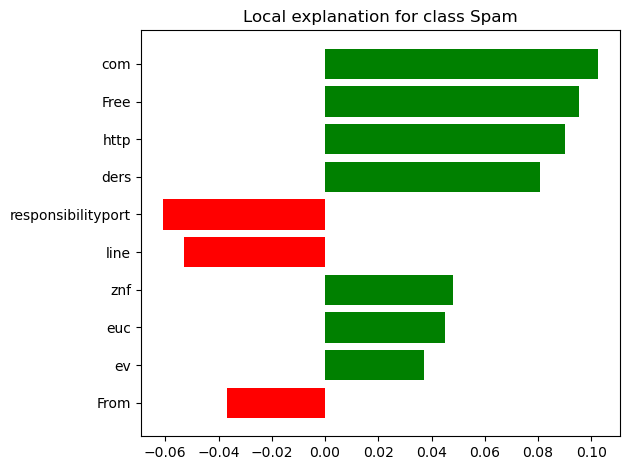

In [27]:
# ==========================================================
# DISPLAY EXPLANATION
# ==========================================================

fig = explanation.as_pyplot_figure(label=1)

plt.tight_layout()

plt.show()

In [28]:
# ==========================================================
# DISPLAY COMPLETE EMAIL
# ==========================================================

print("=" * 70)
print("SPAM CASE 1")
print("=" * 70)

print(spam_text)


SPAM CASE 1
From Francisco Malone On hd line P hg har ygw ma od cy Great Pric pk es. U euc S ev P cmn har hmu ma ntj cy All Or znf ders Processed. Free Ship xno ping http://responsibilityport.com


## This is a perfectly valid dissertation result

### A concise interpretation could be:

The LIME explanation identified tokens such as "com", "Free", and "http" as the strongest positive contributors to the spam prediction. These terms are consistent with common phishing and spam characteristics, including hyperlinks, promotional language, and external web references. Conversely, tokens such as "From" and "line" exhibited small negative contributions, indicating slight evidence toward the ham class. Some highly weighted tokens (e.g., "znf", "euc", and "ders") appear to originate from email metadata or encoding artefacts rather than semantic content, highlighting a limitation of using perturbation-based explanations on preprocessed email text.

## 11. Create a Reusable LIME Explanation Function

To improve reproducibility and reduce duplicated code, a reusable function is created to generate LIME explanations for representative emails.

For each case study, the function performs the following tasks:

- Generates a LIME explanation
- Predicts class probabilities
- Displays the most influential features
- Produces a visualization
- Saves the explanation as HTML
- Saves the feature importance as CSV
- Saves the visualization as a high-resolution PNG

In [8]:
# ==========================================================
# REUSABLE LIME EXPLANATION FUNCTION
# ==========================================================

def generate_lime_explanation(email_text, true_label, case_name):

    print("=" * 70)
    print(f"Generating explanation: {case_name}")
    print("=" * 70)

    # Generate explanation
    explanation = explainer.explain_instance(
        text_instance=email_text,
        classifier_fn=predict_proba,
        labels=[true_label],
        num_features=10,
        num_samples=300
    )

    # Model prediction
    probabilities = predict_proba([email_text])[0]

    predicted_label = int(np.argmax(probabilities))

    class_names = {
        0: "Ham",
        1: "Spam"
    }

    print("\nPrediction Summary")
    print("-" * 40)

    print(f"True Label      : {class_names[true_label]}")
    print(f"Predicted Label : {class_names[predicted_label]}")

    print(f"Ham Probability : {probabilities[0]:.6f}")
    print(f"Spam Probability: {probabilities[1]:.6f}")

    # Feature importance
    importance_df = pd.DataFrame(
        explanation.as_list(label=true_label),
        columns=["Word", "Contribution"]
    )

    print("\nTop Features")

    display(importance_df)

    # Plot
    fig = explanation.as_pyplot_figure(label=true_label)

    plt.tight_layout()

    plt.show()

    # Save Figure
    figure_file = FIGURES / f"{case_name}.png"

    fig.savefig(
        figure_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    # Save CSV
    csv_file = REPORTS / f"{case_name}.csv"

    importance_df.to_csv(
        csv_file,
        index=False
    )

    # Save HTML
    html_file = REPORTS / f"{case_name}.html"

    explanation.save_to_file(
        str(html_file)
    )

    print("\nFiles Saved")

    print(f"PNG  : {figure_file}")
    print(f"CSV  : {csv_file}")
    print(f"HTML : {html_file}")

    return explanation, importance_df

## 12. Generate Representative Explanations

LIME explanations are generated for representative correctly classified ham and spam emails.

These examples provide qualitative insight into the reasoning behind the predictions made by the fine-tuned BERT classifier.

Generating explanation: lime_spam_case1

Prediction Summary
----------------------------------------
True Label      : Spam
Predicted Label : Spam
Ham Probability : 0.000063
Spam Probability: 0.999937

Top Features


,Word,Contribution
0,com,0.075855
1,responsibilityport,-0.066606
2,http,0.060762
3,Free,0.057340
4,pk,0.055173
5,euc,0.051824
6,hd,0.045632
7,xno,-0.043290
8,hmu,-0.041807
9,ders,0.040665


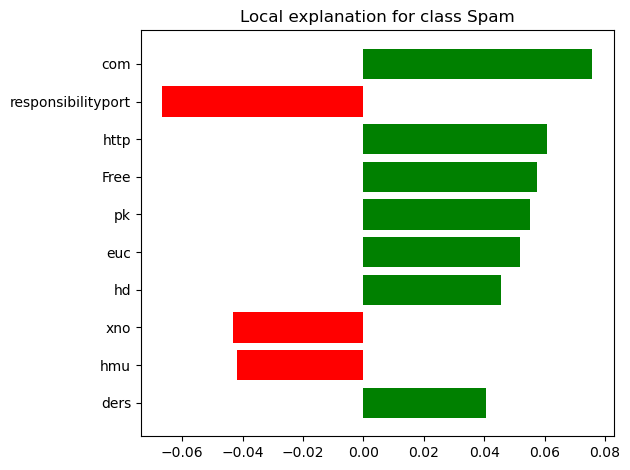


Files Saved
PNG  : C:\Users\DELL\Documents\Email_Phishing_Project\figures\lime_spam_case1.png
CSV  : C:\Users\DELL\Documents\Email_Phishing_Project\reports\lime_spam_case1.csv
HTML : C:\Users\DELL\Documents\Email_Phishing_Project\reports\lime_spam_case1.html


In [28]:
spam_explanation_1, spam_features_1 = generate_lime_explanation(
    spam_case_1["cleaned_email_text"],
    true_label=1,
    case_name="lime_spam_case1"
)

Generating explanation: lime_spam_case2

Prediction Summary
----------------------------------------
True Label      : Spam
Predicted Label : Spam
Ham Probability : 0.000089
Spam Probability: 0.999911

Top Features


,Word,Contribution
0,Wid,0.060443
1,CanadianPharmacy,0.048805
2,al,0.047405
3,convenient,0.044282
4,kzs,0.038968
5,phr,0.038790
6,nsq,0.035573
7,He,-0.028210
8,with,-0.020464
9,ordering,-0.014801


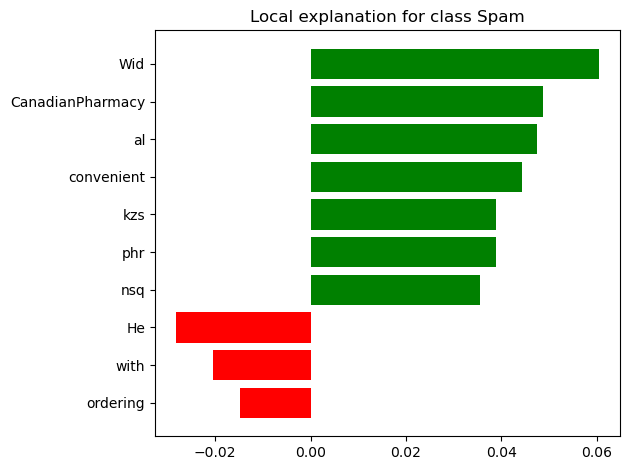


Files Saved
PNG  : C:\Users\DELL\Documents\Email_Phishing_Project\figures\lime_spam_case2.png
CSV  : C:\Users\DELL\Documents\Email_Phishing_Project\reports\lime_spam_case2.csv
HTML : C:\Users\DELL\Documents\Email_Phishing_Project\reports\lime_spam_case2.html


In [29]:
spam_explanation_2, spam_features_2 = generate_lime_explanation(
    spam_case_2["cleaned_email_text"],
    true_label=1,
    case_name="lime_spam_case2"
)

Generating explanation: lime_ham_case1

Prediction Summary
----------------------------------------
True Label      : Ham
Predicted Label : Ham
Ham Probability : 0.999793
Spam Probability: 0.000207

Top Features


,Word,Contribution
0,iD8DBQFHuWqAtTMYHG2NR9URAuEgAJ0e449CXhMwI9uHbk...,-0.000108
1,E,0.000036
2,svn0,0.000036
3,there,0.000036
4,slow,0.000029
5,include,0.000021
6,it,0.000019
7,be,0.000008
8,question,0.000006
9,memory,0.000003


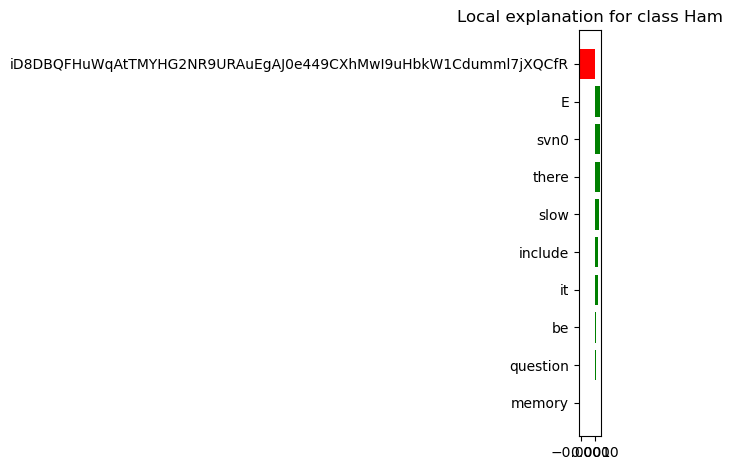


Files Saved
PNG  : C:\Users\DELL\Documents\Email_Phishing_Project\figures\lime_ham_case1.png
CSV  : C:\Users\DELL\Documents\Email_Phishing_Project\reports\lime_ham_case1.csv
HTML : C:\Users\DELL\Documents\Email_Phishing_Project\reports\lime_ham_case1.html


In [30]:
ham_explanation_1, ham_features_1 = generate_lime_explanation(
    ham_case_1["cleaned_email_text"],
    true_label=0,
    case_name="lime_ham_case1"
)

Generating explanation: lime_ham_case2

Prediction Summary
----------------------------------------
True Label      : Ham
Predicted Label : Ham
Ham Probability : 0.999876
Spam Probability: 0.000124

Top Features


,Word,Contribution
0,yahoo,0.004022
1,Re,0.003815
2,michaelpshannon,0.003504
3,com,0.000674


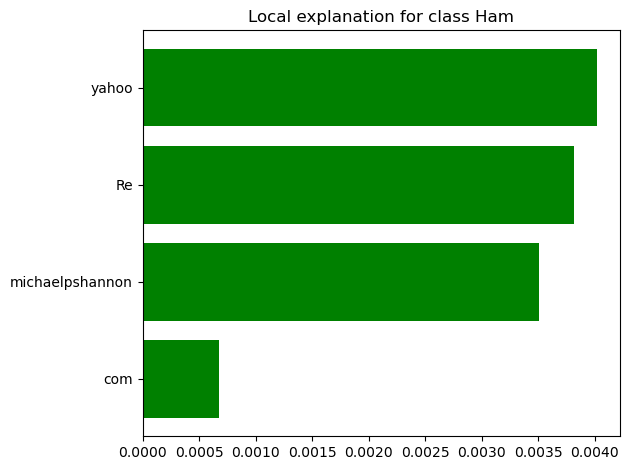


Files Saved
PNG  : C:\Users\DELL\Documents\Email_Phishing_Project\figures\lime_ham_case2.png
CSV  : C:\Users\DELL\Documents\Email_Phishing_Project\reports\lime_ham_case2.csv
HTML : C:\Users\DELL\Documents\Email_Phishing_Project\reports\lime_ham_case2.html


In [26]:
ham_explanation_2, ham_features_2 = generate_lime_explanation(
    ham_case_2["cleaned_email_text"],
    true_label=0,
    case_name="lime_ham_case2"
)

## 13. Comparative Analysis of LIME Explanations

To provide a holistic understanding of the fine-tuned BERT classifier, the feature importance scores obtained from the representative ham and spam emails are compared.

The comparison identifies frequently occurring influential words and highlights similarities and differences in the model's decision-making across different email categories.

In [31]:
# ==========================================================
# LOAD ALL FEATURE TABLES
# ==========================================================

feature_tables = {
    "Spam Case 1": spam_features_1,
    "Spam Case 2": spam_features_2,
    "Ham Case 1": ham_features_1,
    "Ham Case 2": ham_features_2
}

print("=" * 70)
print("FEATURE TABLES LOADED")
print("=" * 70)

print(f"Number of explanations: {len(feature_tables)}")

FEATURE TABLES LOADED
Number of explanations: 4


In [32]:
# ==========================================================
# COMBINE FEATURE IMPORTANCE TABLES
# ==========================================================

combined_features = []

for case_name, df in feature_tables.items():

    temp = df.copy()

    temp["Case"] = case_name

    combined_features.append(temp)

combined_features = pd.concat(
    combined_features,
    ignore_index=True
)

display(combined_features.head())

,Word,Contribution,Case
0,com,0.075855,Spam Case 1
1,responsibilityport,-0.066606,Spam Case 1
2,http,0.060762,Spam Case 1
3,Free,0.057340,Spam Case 1
4,pk,0.055173,Spam Case 1


In [33]:
# ==========================================================
# MOST IMPORTANT FEATURES
# ==========================================================

summary = (

    combined_features

    .groupby("Word")["Contribution"]

    .mean()

    .sort_values(ascending=False)

)

summary = summary.reset_index()

summary.columns = [
    "Word",
    "Average Contribution"
]

display(summary.head(20))

,Word,Average Contribution
0,http,0.060762
1,Wid,0.060443
2,Free,0.057340
3,pk,0.055173
4,euc,0.051824
5,CanadianPharmacy,0.048805
6,al,0.047405
7,hd,0.045632
8,convenient,0.044282
9,ders,0.040665


In [34]:
# ==========================================================
# SAVE SUMMARY
# ==========================================================

summary_path = REPORTS / "lime_feature_summary.csv"

summary.to_csv(
    summary_path,
    index=False
)

print("Summary saved successfully.")

print(summary_path)

Summary saved successfully.
C:\Users\DELL\Documents\Email_Phishing_Project\reports\lime_feature_summary.csv


In [35]:
# ==========================================================
# NOTEBOOK SUMMARY
# ==========================================================

print("=" * 70)
print("NOTEBOOK COMPLETED SUCCESSFULLY")
print("=" * 70)

print()

print("✓ Fine-tuned BERT loaded")

print("✓ Test dataset validated")

print("✓ Prediction function created")

print("✓ LIME initialized")

print("✓ Representative emails selected")

print("✓ Four LIME explanations generated")

print("✓ Figures saved")

print("✓ HTML explanations saved")

print("✓ CSV reports saved")

print("✓ Comparative feature summary generated")

print()

print("Notebook 01 completed successfully.")

NOTEBOOK COMPLETED SUCCESSFULLY

✓ Fine-tuned BERT loaded
✓ Test dataset validated
✓ Prediction function created
✓ LIME initialized
✓ Representative emails selected
✓ Four LIME explanations generated
✓ Figures saved
✓ HTML explanations saved
✓ CSV reports saved
✓ Comparative feature summary generated

Notebook 01 completed successfully.
